Typical rigidity values used in the calculation are 30 (McCaffrey, 2008) and 49 GPa (Kagan and Jackson, 2013)

$M_{w}=(\log _{10}M_{0}-9.1)/1.5$

$M_0 =μAslip$

In [ ]:
import numpy as np

def moment(mu, area, slip):
    """
    Compute seismic moment (M0).

    Parameters
    ----------
    mu : float
        Rigidity (Pa)
    area : float
        Fault area (m^2)
    slip : float
        Average slip (m)

    Returns
    -------
    float
        Seismic moment (N·m)
    """
    return mu * area * slip


def moment_to_mw(M0):
    """
    Convert seismic moment to moment magnitude (Mw).
    """
    return (np.log10(M0) - 9.1) / 1.5


def mw_to_moment(Mw):
    """
    Convert moment magnitude to seismic moment (M0).
    """
    return 10 ** (1.5 * Mw + 9.1)


def slip_from_moment(M0, mu, area):
    """
    Solve for average slip given moment.
    """
    return M0 / (mu * area)


def area_from_moment(M0, mu, slip):
    """
    Solve for rupture area given moment.
    """
    return M0 / (mu * slip)

def calc_M0(mu,slip,area):
    """
    Solve for the total moment (in N*m) given the rigidity, average slip (m), and rupture area (m^2)
    """
    M0 = mu * area * slip # in N*m
    return M0



In [ ]:
import numpy as np

mu = 30e9 #Pa
A = 141000*487000 # m^2
slip = 10 # m


M0 = calc_M0(mu,A,slip)
Mw = moment_to_mw(M0)
print(Mw)

8.809246219059784


# Example: Compare M8.8 to M9

In [11]:
Mw1952 = 9.0
M0_1952 = mw_to_moment(Mw1952)

# Let's assume constant rigidity and slip
mu = 30e9 #GPa
slip = 10 # m

area_1952 = area_from_moment(M0_1952, mu, slip)
print(f"{int(area_1952/(1000*1000))} km^2")


Mw2025 = 8.8
M0_2025 = mw_to_moment(Mw2025)
area_2025 = area_from_moment(M0_2025, mu, slip)
print(f"{int(area_2025/(1000*1000))} km^2")


132702 km^2
66508 km^2


# make a more general comparison

In [12]:
# Define a range of Mw values
Mw_range = np.linspace(7.5, 9.5, 50)  # adjust range/resolution as needed

# Compute M0 and area for all Mw values
M0_range = mw_to_moment(Mw_range)
area_range = area_from_moment(M0_range, mu, slip)

# Convert to km^2 for readability
area_km2 = area_range / 1e6

# Print a few sample values
for Mw, area in zip(Mw_range[::10], area_km2[::10]):
    print(f"Mw {Mw:.2f} -> {area:,.0f} km^2")

Mw 7.50 -> 746 km^2
Mw 7.91 -> 3,056 km^2
Mw 8.32 -> 12,513 km^2
Mw 8.72 -> 51,241 km^2
Mw 9.13 -> 209,826 km^2


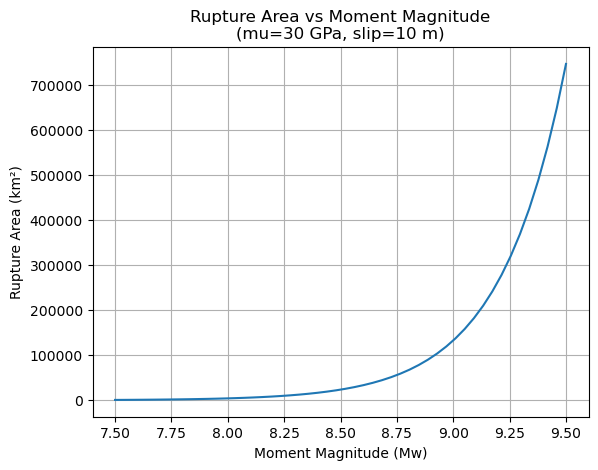

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(Mw_range, area_km2)
plt.xlabel("Moment Magnitude (Mw)")
plt.ylabel("Rupture Area (km²)")
plt.title("Rupture Area vs Moment Magnitude\n(mu=30 GPa, slip=10 m)")
plt.grid()

# # Log scale is often more informative due to exponential scaling
# plt.yscale("log")

plt.show()